In [1]:
import os
os.chdir(r'C:\Users\arif\OneDrive - Higher Education Commission\Teaching\Courses\machine learning\Spring 2026\Code')

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from timeseires.utils.to_split import to_split
from timeseires.utils.multivariate_multi_step import multivariate_multi_step
from timeseires.utils.multivariate_single_step import multivariate_single_step
from timeseires.utils.univariate_multi_step import univariate_multi_step
from timeseires.utils.univariate_single_step import univariate_single_step
from timeseires.utils.CosineAnnealingLRS import CosineAnnealingLRS
from timeseires.callbacks.EpochCheckpoint import EpochCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint
from timeseires.callbacks.TrainingMonitor import TrainingMonitor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Add
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv1D,TimeDistributed
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten,MaxPooling1D,Concatenate,AveragePooling1D, GlobalMaxPooling1D, Input
from tensorflow.keras.models import Sequential,Model
import pandas as pd
import time, pickle
import numpy as np
import tensorflow.keras.backend as K
import tensorflow
from tensorflow.keras.layers import Input, Reshape, Lambda
from tensorflow.keras.layers import Layer, Flatten, LeakyReLU, concatenate, Dense
from tensorflow.keras.regularizers import l2
import glob
import h5py
import matplotlib.pyplot as plt
from keras.callbacks import Callback

Using TensorFlow backend.


In [3]:
#lookback = 24
model = None
start_epoch = 0
time_steps=24
num_features=21

In [4]:
def CNN():
    input_data = Input(shape=(time_steps, num_features))
    x1 = Conv1D(16, 2, activation="relu")(input_data)
    x2 = Conv1D(16, 2, activation="relu")(x1)
    flatten = Flatten()(x2)
    output_data = Dense(1)(flatten)
    model = Model(input_data, output_data)
    return model

In [5]:
model1 = CNN()
model1.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 24, 21)]          0         
_________________________________________________________________
conv1d (Conv1D)              (None, 23, 16)            688       
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 22, 16)            528       
_________________________________________________________________
flatten (Flatten)            (None, 352)               0         
_________________________________________________________________
dense (Dense)                (None, 1)                 353       
Total params: 1,569
Trainable params: 1,569
Non-trainable params: 0
_________________________________________________________________


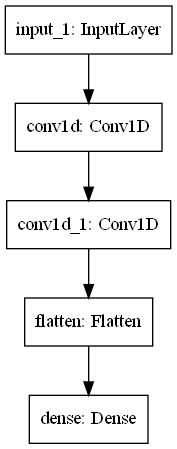

In [6]:
tensorflow.keras.utils.plot_model(model1 )

In [7]:
checkpoints = r'C:\Users\arif\Downloads\delete\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
OUTPUT_PATH = r'C:\Users\arif\Downloads\delete'
FIG_PATH = os.path.sep.join([OUTPUT_PATH,"\history.png"])
JSON_PATH = os.path.sep.join([OUTPUT_PATH,"\history.json"])

In [8]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]

In [9]:
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model =CNN()
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] compiling model...


In [10]:
import os
path_dataset =r'C:\Users\arif\OneDrive - Higher Education Commission\Teaching\Courses\machine learning\Spring 2026\Code'
path_tr = os.path.join(path_dataset, 'train.csv')
df_tr = pd.read_csv(path_tr)
train_set = df_tr.iloc[:].values
path_v = os.path.join(path_dataset, 'validation.csv')
df_v = pd.read_csv(path_v)
validation_set = df_v.iloc[:].values 
path_te = os.path.join(path_dataset, 'test.csv')
df_te = pd.read_csv(path_te)
test_set = df_te.iloc[:].values 

path_scaler = os.path.join(path_dataset, 'AEPscaler.pkl')
scaler         = pickle.load(open(path_scaler, 'rb'))

train_set.shape, validation_set.shape, test_set.shape

((860, 21), (90, 21), (30, 21))

In [12]:
time_steps=24
num_features=21

In [11]:
start = time.time()
train_X , train_y = univariate_multi_step(train_set, time_steps, target_col=0,target_len=1)
validation_X, validation_y = univariate_multi_step(validation_set, time_steps, target_col=0,target_len=1)
test_X, test_y = univariate_multi_step(test_set, time_steps, target_col=0,target_len=1)
print('Time Consumed', time.time()-start, "sec")

Time Consumed 0.0045928955078125 sec


In [12]:
epochs = 60
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,verbose = verbose)

Train on 835 samples, validate on 65 samples
Epoch 1/60
544/835 [==================>...........] - ETA: 4s - loss: 0.2997 - mae: 0.2997 - mape: 173.8574  
Epoch 00001: val_loss improved from inf to 0.13328, saving model to C:\Users\arif\Downloads\delete\E1-cp-0001-loss0.13.h5
835/835 [==============================] - 9s 11ms/sample - loss: 0.2565 - mae: 0.2565 - mape: 145.0412 - val_loss: 0.1333 - val_mae: 0.1333 - val_mape: 38.0511
Epoch 2/60
704/835 [========================>.....] - ETA: 0s - loss: 0.1083 - mae: 0.1083 - mape: 69.5680
Epoch 00002: val_loss improved from 0.13328 to 0.07530, saving model to C:\Users\arif\Downloads\delete\E1-cp-0002-loss0.08.h5
835/835 [==============================] - 0s 240us/sample - loss: 0.1033 - mae: 0.1033 - mape: 63.0643 - val_loss: 0.0753 - val_mae: 0.0753 - val_mape: 28.4069
Epoch 3/60
704/835 [========================>.....] - ETA: 0s - loss: 0.0636 - mae: 0.0636 - mape: 37.1999
Epoch 00003: val_loss improved from 0.07530 to 0.04900, savin

In [13]:

model = load_model(r'C:\Users\arif\Downloads\delete\E1-cp-0055-loss0.03.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

Mean Absolute Error (MAE): 12401.71
Median Absolute Error (MedAE): 12529.37
Mean Squared Error (MSE): 153967995.29
Root Mean Squared Error (RMSE): 12408.38
Mean Absolute Percentage Error (MAPE): 79.25 %
Median Absolute Percentage Error (MDAPE): 79.69 %


y_test_unscaled.shape=  (5, 1)
y_pred.shape=  (5, 1)


In [16]:
checkpoints = r'C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E2-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
model=r'C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E1-cp-0058-loss0.01.h5'
start_epoch= 58

In [17]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model = PC.build(time_steps=24, num_features=21, reg=0.0005)
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] loading C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E1-cp-0058-loss0.01.h5...
[INFO] old learning rate: 0.0010000000474974513
[INFO] new learning rate: 9.999999747378752e-05


In [18]:
epochs = 10
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)

Epoch 1/10
2651/2653 [============================>.] - ETA: 0s - loss: 0.0064 - mae: 0.0064 - mape: 711.7792
Epoch 1: val_loss improved from inf to 0.00659, saving model to C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E2-cp-0001-loss0.01.h5
2653/2653 [==============================] - 36s 13ms/step - loss: 0.0064 - mae: 0.0064 - mape: 711.3610 - val_loss: 0.0066 - val_mae: 0.0066 - val_mape: 4.3460
Epoch 2/10
2644/2653 [============================>.] - ETA: 0s - loss: 0.0063 - mae: 0.0063 - mape: 578.1265
Epoch 2: val_loss improved from 0.00659 to 0.00642, saving model to C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E2-cp-0002-loss0.01.h5
2653/2653 [==============================] - 10s 4ms/step - loss: 0.0063 - mae: 0.0063 - mape: 576.2668 - val_loss: 0.0064 - val_mae: 0.0064 - val_mape: 4.2309
Epoch 3/10
2646/2653 [============================>.] - ETA: 0s - loss: 0.0063 - mae: 0.0063 - mape: 551.6437
Epoch 3: val_loss did not improve from 0.0064

In [19]:

model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\checkpoint\ML Lab\lab8\E2-cp-0008-loss0.01.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

379/379 [==============================] - 1s 2ms/step
Mean Absolute Error (MAE): 103.3
Median Absolute Error (MedAE): 82.18
Mean Squared Error (MSE): 18772.44
Root Mean Squared Error (RMSE): 137.01
Mean Absolute Percentage Error (MAPE): 0.71 %
Median Absolute Percentage Error (MDAPE): 0.57 %


y_test_unscaled.shape=  (12105, 1)
y_pred.shape=  (12105, 1)


# lab report 

## Lab 1